In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

from datetime import datetime as dt
from datetime import timedelta
import os

import matplotlib.cm as cm

pd.options.mode.chained_assignment = None 

In [5]:
import numpy as np

actual_value = np.array([1, 1, 1, 1, 1, 0])
x_2 = np.array([1, 1, 1, 1, 1, 0])

# take square of differences and sum them
l2 = np.sum(np.power((actual_value),2))

# take the square root of the sum of squares to obtain the L2 norm
l2_norm = np.sqrt(l2)
print(l2_norm*2)

sum_x = np.array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0])
l2 = np.sum(np.power((sum_x),2))

# take the square root of the sum of squares to obtain the L2 norm
l2_norm = np.sqrt(l2)
print(l2_norm)


4.47213595499958
3.1622776601683795


In [4]:
df1['ip.src'].hist()

<AxesSubplot:>

Error in callback <function flush_figures at 0x00000133DEC18700> (for post_execute):


KeyboardInterrupt: 

In [600]:
for i in df1_f['queryText']:
    if "ipSrcNet" in i:
        print(i)

ipSrc = 1017997831 and ipSrcNet = 162196 and ipDstNet = 42251 and ipDstHost = 208160
ipSrcNet = 162196 and ipSrcHost = 4976
ipSrcNet = 42138 and ipDst = 1166948693 and ipDstNet = 54223 and ipDstHost = 235229
ipSrc = 1017997831 and ipSrcNet = 162196 and ipDst = 906596711 and ipDstNet = 42251 and ipDstHost = 208160
ipSrc = 1017997831 and ipSrcNet = 162196 and ipDstHost = 208160
ipSrcNet = 162196 and ipDstHost = 208160
ipSrcNet = 162196 and ipDst = 906596711 and ipDstNet = 42251 and ipDstHost = 208160
ipSrc = 1017997831 and ipSrcNet = 162196 and ipDst = 906596711 and ipDstNet = 42251 and ipDstHost = 208160
ipSrcNet = 162196 and ipDst = 906596711 and ipDstNet = 42251 and ipDstHost = 208160
ipSrcNet = 162196 and ipSrcHost = 4976 and ipDstHost = 208160
ipSrcNet = 162196 and ipSrcHost = 4976 and ipDst = 906596711 and ipDstHost = 208160
ipSrcNet = 162196 and ipDstHost = 208160
ipSrcNet = 162196 and ipSrcHost = 4976 and ipDstNet = 42251 and ipDstHost = 208160
ipSrc = 1017997831 and ipSrcNet = 1

In [2]:
folder_name = "C:/Users/s162378/OneDrive - TU Eindhoven/Documents/GitHub/DSCM/Figures/SNMP_tightBound/"

In [3]:
def test_assumption(df):
    # Function that analyzes for which failed and non-failed queries the assumption exactAnswer/N <= epsCM^p holds.
    b_sizes = sorted(df['maxSize'].unique())
    N_sizes = sorted(df['streamSize'].unique())
    dist_preds = sorted(df['numPredicates'].unique())
    epses = sorted(df['eps'].unique())
    df.loc[:,'assHolds'] = df.loc[:,'exactAnswer']/df.loc[:,'streamSize']
    
    for N in N_sizes:
        # Per p, analyze four groups: Bound holds and not holds x assumption holds and fails.
        df_n = df[df['streamSize'] == N]
        for p in dist_preds:
            df_p = df_n[df_n['numPredicates'] == p]
            for b in b_sizes:
                df_b = df_p[df_p['maxSize'] == b]
                for eps in epses:
                    if eps != 0.05:
                        continue
                    df_e = df_b[df_b['eps'] == eps]
                    dfHolds = df_e[df_e.loc[:,'assHolds'] <= df_e.loc[:,'epsCM']**p]
                    dfFails = df_e[df_e.loc[:,'assHolds'] > df_e.loc[:,'epsCM']**p]

                    hold_in = len(dfHolds[dfHolds['withinTightBound'] == True])
                    hold_out = len(dfHolds[dfHolds['withinTightBound'] == False])
                    fails_in = len(dfFails[dfFails['withinTightBound'] == True])
                    fails_out = len(dfFails[dfFails['withinTightBound'] == False])
                    xlabel = ""
                    ylabel = "frequency"
                    title = "Setting for N = {}, p = {}, B = {}, eps = {}".format(N, p, b, eps)
                    x = [hold_in, hold_out, fails_in, fails_out]
                    #for i in x:
                    #    print(x)
                    fig, ax = plt.subplots()
                    ax.bar(["Ass Holds In Bound", "Ass Holds Out Bound", "Ass Fails In bound", "Ass fails out bound"], x)

                    ax.set(xlabel=xlabel,ylabel=ylabel,title=title)
                    plt.show()
                

In [4]:
df_mem = pd.read_csv("output/mult_{}_2023-07-07.csv".format(dataset), header=0)
df_mem = preprocess_mem(df_mem)
#plots_per_setting(df_mem)

NameError: name 'dataset' is not defined

In [26]:
def pipeline(dataset, p = 2):
    #df = read(dataset, False)
    df_mem = pd.read_csv("mult_{}_2023-07-07.csv".format(dataset), header=0)
    #df1 = df.copy()
    
    #get_used_attrs(df)
    #df = preprocess(df, p)
    df_mem = preprocess_mem(df_mem)
    plots_per_setting(df_mem)
    """
    test_proof(df)
    test_proof_tight(df)
    test_query_equality(df)
    plots_per_setting(df, df_mem)
    test_exact_answer(df)
    aggr_plots(df)
    """
    
    df = read(dataset, compare=True)
    df = preprocess(df, p)
    compareBaselinePlot(df, dataset)
    

In [27]:
def read(dataset, compare):
    today = dt.now().date()
    yesterday = dt.now() - timedelta(1)
    dir = "./"  #path to directory

    fileList = []
    for file in os.listdir(dir):
        filetime = dt.fromtimestamp(
                os.path.getctime(dir + file))   
        if filetime.date() == today:
            if 'results' in file:
                fileList.append(file)
    if compare:
        #df = pd.read_csv("outputODC/results_false_CAIDA_2023-07-09.csv".format(dataset), header=0)
        df = pd.read_csv(filename, header = 0)
    else:
        df = pd.read_csv("outputODC/results_false_{}_2023-06-26.csv".format(dataset), header=0)
    return getBins(df)


In [28]:
def get_used_attrs(df):
    attrs = []
    for i in df['queryText'].unique():
        splitted = i.split(' ')
        for s in splitted:
            if "=" in s:
                continue
            if s.isnumeric():
                continue
            if s not in attrs:
                attrs.append(s)
    print("{} Distinct attributes used in predicates".format(len(attrs)))
    

In [29]:
def preprocess(df1, p, keepAll = False):
    #last_streamSize = df1['streamSize'].iloc[-1]
    #df = df1[df1['streamSize'] != last_streamSize]
    df = df1
    if 'relError' in df.columns[df.dtypes == 'object']:
        df.loc[:,'relError'] = df['relError'].apply(lambda x: x.replace(',','.')).astype({'relError': float})
    if 'epsError' in df.columns[df.dtypes == 'object']:
        df.loc[:,'epsError'] = df.loc[:,'epsError'].apply(lambda x: x.replace(',','.')).astype({'epsError': float})
    #df.loc[:,'altEpsError'] = df.loc[:,'absError']/df.loc[:,'streamSize'] # Alternative epsError.
    df.loc[:,'Sketch Memory (Mb)'] = df.loc[:,'memUsageSynopsis']/1e6
    df.loc[:,'Dataset Memory (Mb)'] = df.loc[:,'memUsageDataset']/1e6
    df.loc[:,'Speedup'] = df.loc[:,'exactTime']/df.loc[:,'estTime']
    df.loc[:,'Time Est (ms)'] =  df.loc[:,'estTime']
    df.loc[:,'Avg Update Time (ms)'] =  df.loc[:,'Avg Update Time']
    df.loc[:,'Time exact (ms)'] = df.loc[:,'exactTime']
    df.loc[:,'relMemFootprint'] = df.loc[:,'Sketch Memory (Mb)']/df.loc[:,'Dataset Memory (Mb)']
    df.loc[:, 'thrm33case2'] = np.where(df['setting'] != 'OmniSketch', True, df['thrm33case2'])
    df.loc[:,'RAM'] = df.loc[:,'RAM']/(8e6)
    if not keepAll:
        df = df[df['numPredicates'] == p]
    df.loc[:,'altAbsError'] = np.where(df['setting'] == 'OmniSketch',
                                       abs(df.loc[:,'case2Estimate'] - df.loc[:, 'exactAnswer']),
                                       df['absError'])
    df.loc[:, 'altEpsError'] = df['altAbsError']/df['streamSize'] # Alternative epsError.
    df.loc[:,'altNullAbsError'] = np.where(df['thrm33case2'] == False,
                                           df.loc[:,'exactAnswer'],
                                           abs(df.loc[:,'estimate'] - df.loc[:,'exactAnswer']))
    df.loc[:, 'altNullEpsError'] = df['altNullAbsError']/df['streamSize']
    #df.loc[:, 'altNullEpsError'] = df.loc[:'altNullAbsError']/df.loc[:,'streamSize'] # Alternative epsError.
    
    #df = df[df['exactAnswer'] > 1000]
    #{Main.depth, Main.width, Main.maxSize, Main.b};
    #{d, w, numRows, countersPerRow, levels, k};
    df['d'] = 0
    df['w'] = 0
    df['B'] = 0
    df['b'] = 0
    df['dCS'] = 0
    df['wCS'] = 0
    df['levels'] = 0
    df['k'] = 0
    for k, v in df.iterrows():
        pars = [int(i) for i in list(v['parameters'].replace("[", "").replace("]", "").split(", "))]
        if v['setting'] == "OmniSketch":
            df.loc[k, 'd'] = pars[0]
            df.loc[k, 'w'] = pars[1]
            df.loc[k, 'B'] = pars[2]
            df.loc[k, 'b'] = pars[3]
        if v['setting'] == "Hydra":
            df.loc[k, 'd'] = pars[0]
            df.loc[k ,'w'] = pars[1]
            df.loc[k, 'dCS'] = pars[2]
            df.loc[k, 'wCS'] = pars[3]
            df.loc[k, 'levels'] = pars[4]
            df.loc[k, 'k'] = pars[5]
    return df

In [30]:
def preprocess_mem(df1):
    df = df1
    df.loc[:,'Sketch Memory (Mb)'] = df.loc[:,'memUsageSynopsis']/1e6
    df.loc[:,'Dataset Memory (Mb)'] = df.loc[:,'memUsageDataset']/1e6
    df.loc[:,'relMemFootprint'] = df.loc[:,'Sketch Memory (Mb)']/df.loc[:,'Dataset Memory (Mb)']

    return df

In [31]:
# Plot functions.
 
def simple(x, y, xlabel, ylabel, title, df):
    
    title = "{} {}".format(title, dataset)
    t = df[x]
    s = df[y]

    fig, ax = plt.subplots()
    ax.plot(t,s)
    #ax = df.plot(x, y)
    ax.set(xlabel=xlabel,ylabel=ylabel,title=title)
    #ax.grid()

    fig.savefig(folder_name + "{}.pdf".format(title.replace(" ", "_")))
    plt.show()
    
def scatter(x, y, xlabel, ylabel, title, df):
    
    title = "{} {}".format(title, dataset)
    t = df[x]
    s = df[y]

    fig, ax = plt.subplots()
    ax.scatter(t, s)

    ax.set(xlabel=xlabel,ylabel=ylabel,title=title)
    #ax.grid()

    fig.savefig(folder_name + "{}.pdf".format(title.replace(" ", "_")))
    plt.show()
    
def scatter_color_num(x, y, c, xlabel, ylabel, clabel, title, df):
    
    title = "{} {}".format(title, dataset)
    t = df[x]
    s = df[y]
    
    categories = np.unique(df[c])
    colors = cm.cividis(np.linspace(0, 1, len(categories)))
    colordict = dict(zip(categories, colors))  

    fig, ax = plt.subplots()
    ax.scatter(t, s, c=df[c].apply(lambda x:colordict[x]))

    ax.set(xlabel=xlabel,ylabel=ylabel,title=title)
   
    handles = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colordict.items()]
    leg_title = {'maxSize':'B',
                 'eps':'\u03B5',
                 'relMemFootprint':'Rel. Memory footprint', 
                'deltaDSConstraintHolds': "Constraint Holds",
                'numAttributes': "Number of Attributes"}
    
    if c == 'relMemFootprint' or c == 'numAttributes':
        cbar = plt.colorbar(cm.ScalarMappable(norm=None, cmap='cividis'), ax=ax)
        cbar.ax.get_yaxis().set_ticks([])
        for j, lab in enumerate(sorted(df[c].unique())):
            cbar.ax.text(.5, .5*(2 * j + 1) / len(df[c].unique()), lab, ha='center', va='center')
        cbar.ax.get_yaxis().labelpad = 15
        cbar.ax.set_ylabel('# of attributes', rotation=270)
        
    else: 
        ax.legend(title=leg_title[c], handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    fig.savefig(folder_name + "{}.pdf".format(title.replace(" ", "_")), format="pdf", bbox_inches="tight")
    plt.show()

In [32]:
def test_proof_tight(df):
    num_rejections = df[df['withinTightBound'] == False].iloc[:,0].size
    num_total = df.iloc[:,0].size

    if num_rejections/num_total > 0.05:
        print("Tight bound rejected with ratio {}".format(num_rejections/num_total))
        return False
    else:
        print("Tight bound holds with ratio {}".format(num_rejections/num_total))
        return True

In [33]:
def test_proof(df):
    num_rejections = df[df['withinThreshold'] == False].iloc[:,0].size
    num_total = df.iloc[:,0].size

    if num_rejections/num_total > 0.05:
        print("Proof rejected with ratio {}".format(num_rejections/num_total))
        return False
    else:
        print("Proof holds with ratio {}".format(num_rejections/num_total))
        return True

In [34]:
def test_query_equality(df):
    sizes = df['streamSize'].unique()
    for s1 in range(sizes.size):
        small = df[df['streamSize'] == sizes[s1]]
        for s2 in range(sizes.size):
            if s1 != s2:
                large = df[df['streamSize'] == sizes[s2]]
                cnt = 0
                for i in large['queryID'].unique():
                    if i not in small['queryID'].unique():
                        cnt+=1
                        print("not in small: " + str(i))
                for i in small['queryID'].unique():
                    if i not in large['queryID'].unique():
                        cnt+=1
                        print("not in large: " + str(i))
                if cnt>0:
                    print("Something is wrong, not all queries are same for different stream sizes.")

In [35]:
def plots_per_setting(df, df_mem):
    streamSizes = df['streamSize'].unique()
    
    # Plots per setting
    df1 = df[df['queryID'] == df['queryID'].iloc[0]]
    #for i in sorted(df['eps'].unique()):
    #    df2 = df1[df1['eps'] == i]
    #    # Plot sketch memory / dataset memory for different maxSize with epsilon == 0.1
    #    scatter_color_num('Dataset Memory (Mb)', 'Sketch Memory (Mb)', 'maxSize',
    #            "Dataset Size (Mb)", "Memory footprint (Mb)", 'Max Sample Size',
    #            "Memory footprint per dataset size for \u03B5 = {}".format(i), df2)
    
    scatter_color_num('Dataset Memory (Mb)', 'Sketch Memory (Mb)', 'eps',
                "Dataset Size (Mb)", "Memory footprint (Mb)", "Epsilon",
                "Memory footprint per dataset size", df1)
    
    #df3 = df2[df2['numAttributes'] != 2]
    #df4 = df3[df3['numAttributes'] != 7]
    scatter_color_num('Dataset Memory (Mb)', 'Sketch Memory (Mb)', 'numAttributes',
                "Dataset Size (Mb)", "Memory footprint (Mb)", "Number of Attributes",
                "Memory footprint per dataset size per number of attributes", df_mem)
    
    for i in sorted(df['maxSize'].unique()):
        df3 = df[df['maxSize'] == i]
        # Plot sketch memory / dataset memory for different Epsilon with set MaxSize == 5000
        scatter_color_num('Dataset Memory (Mb)', 'Sketch Memory (Mb)', 'eps',
                "Dataset Size (Mb)", "Memory footprint (Mb)", "Epsilon",
                "Memory footprint per dataset size for B = {}".format(i), df3)
    
    #scatter_color_num('eps', 'maxSize', 'relMemFootprint',
    #        "Epsilon", "Max Sample Size", "Relative Memory Footprint",
    #        "Relative memory footprint for \u03B5, B settings.", df1)
    
    

In [36]:
def test_exact_answer(df):
    print("Exact is 0 count: " + str(len(df[df['exactAnswer'] == 0].index)))
    

In [37]:

def grouped_plot(df, gb_lst, aggr, x_k, y_k, const_column, xlabel, ylabel, title, constColumnBool=False, includeMax = False, plotStd = False):
    # Gather correct data.
    title = "{} {}".format(title, dataset)
    if constColumnBool:
        df = df[df[const_column] == df[const_column].iloc[-1]]
    
    df_gb = df.groupby(by=gb_lst)
    y = []
    std_lst = []
    max_lst = []
    eps_lst = []
    x = []
    for k, v in df_gb:
        #if k[1] == B_val:
        avg = v[aggr].mean()
        std = v[aggr].std()#[aggr]
        maxError = v[aggr].max()#[aggr]
        y.append(avg)
        std_lst.append(std)
        max_lst.append(maxError)
        x.append(k[x_k])
        eps_lst.append(k[y_k])
                    

    # Plot Avg. observed error
    fig, ax = plt.subplots()
    if constColumnBool:
        if plotStd:
            ax.errorbar(x, y, yerr = std_lst)
        else:
            ax.plot(x, y)
    else:
        ax.scatter(x, y)
    if includeMax:
        ax.scatter(x, max_lst)
        for i, txt in enumerate(eps_lst):
            ax.annotate("\u03B5 = {}".format(txt), (x[i], max_lst[i]))
    for i, txt in enumerate(eps_lst):
        ax.annotate("\u03B5 = {}".format(txt), (x[i], y[i]))
    ax.set(xlabel=xlabel,ylabel="Avg. "+ylabel,title="Avg. "+ title)

    fig.savefig(folder_name + "{}.pdf".format(title.replace(" ", "_")), format="pdf", bbox_inches="tight" )
    plt.show()
    
    # Plot Max Observed error
    """
    fig, ax = plt.subplots()
    ax.scatter(x, max_lst)
    for i, txt in enumerate(eps_lst):
        ax.annotate("\u03B5 = {}".format(txt), (x[i], max_lst[i]))
    ax.set(xlabel=xlabel,ylabel="Maximal " + ylabel,title="Max. " + title)
    fig.savefig(folder_name + "Max_{}.pdf".format(title.replace(" ", "_")), format="pdf", bbox_inches="tight" )
    plt.show()
    """



In [38]:
def aggr_plots(df):
    #for i in sorted(dfTotal['maxSize'].unique()):
        #df = dfTotal[dfTotal['maxSize'] == i]
    
    df = df[df['maxSize'] == 5000]
    # observed error / sketch mem
    grouped_plot(df,
             ["eps", "Sketch Memory (Mb)"],
             "epsError", 1, 0, "streamSize", "Sketch Memory (Mb)", "Observed Error",
             "observed error per memory footprint", True, True) 

    # relative error / sketch mem
    grouped_plot(df,
             ["eps", "Sketch Memory (Mb)"],
             "relError", 1, 0, "streamSize", "Sketch Memory (Mb)", "Relative Error",
             "relative error per memory footprint", True, True) 

    # observed error / number of predicates
    grouped_plot_pred(df, ["eps", "Sketch Memory (Mb)", "numPredicates"],
                 "epsError",1, 0, "Sketch Memory (Mb)", "Observed Error",
                 "observed error per number of predicates", "numPredicates", 2)

    # relative error / number of predicates
    grouped_plot_pred(df, ["eps", "Sketch Memory (Mb)", "numPredicates"],
                 "relError",1, 0, "Sketch Memory (Mb)", "Relative Error",
                 "relative error per number of predicates", "numPredicates", 2)


    # observed error / number of predicates
    grouped_plot_pred(df, ["eps", "eps", "numPredicates"],
                 "epsError",1, 0, "Epsilon", "Observed Error",
                 "observed error per constructed eps per number of predicates", "numPredicates", 2, includeMax = True)

    # relative error / number of predicates
    grouped_plot_pred(df, ["eps", "eps", "numPredicates"],
                 "relError",1, 0, "Epsilon", "Relative Error",
                 "relative error per constructed eps per number of predicates", "numPredicates", 2, includeMax = True)

    # Running time cannot yet be analyzed. Will need multiple trials.

    """
    df1 = df[df['eps'] == df['eps'].iloc[0]]
    # running time / datset
    grouped_plot(df1,
             ["eps", "Dataset Memory (Mb)"],
             "Time Est (ms)", 1, 0, "eps", "Dataset Memory (Mb)", "Running time (ms)",
             "Running time per dataset size for B = {}".format(i), True) #"eps", before DAtast Memorty

    # speedup / sketch mem
    grouped_plot(df,
             ["eps", "Sketch Memory (Mb)"],
             "Speedup", 1, 0, "streamSize", "Sketch Memory (Mb)", "Speedup",
             "speedup per memory footprint for B = {}".format(i), True)
    """

    
    
    

In [39]:

def grouped_plot_pred(df, gb_lst, aggr, x_k, y_k, xlabel, ylabel, title,z,  z_k=None, z_v=None, includeMax = False, plotStd = False):
    # Gather correct data.
    title = "{} {}".format(title, dataset)
    df = df[df['streamSize'] == df['streamSize'].iloc[-1]]
    
    print("Stream length is {}".format(df['streamSize'].iloc[-1]))
    
    print("Dataset size is {}".format(df['Dataset Memory (Mb)'].iloc[-1]))
    df_gb = df.groupby(by=gb_lst)
    z_size = len(df[z].unique())
    eps_size = len(df['eps'].unique())
    
    eps_map = {}
    for i, eps in enumerate(df['eps'].unique()):
        eps_map[eps] = i
    pred_map = {}
    for i, pred in enumerate(df[z].unique()):
        pred_map[pred] = i
    z_mean = z_max = z_std = z_eps = z_x = np.zeros([z_size, eps_size])
    for k, v in df_gb:
        if z_v != None and k[z_k] <= z_v:
            continue
        eps_idx = eps_map[k[y_k]]
        pred_idx = pred_map[k[z_k]]
        z_mean[pred_idx][eps_idx] = v[aggr].mean()
        z_std[pred_idx][eps_idx] = v[aggr].std()
        z_max[pred_idx][eps_idx] = v[aggr].max()
        z_eps[pred_idx][eps_idx] = k[y_k]
        z_x[pred_idx][eps_idx] = k[x_k]
                    

    # Plot Avg. observed error
    fig, ax = plt.subplots()
    markers = ['^', "o", "v", "s", "d", "h"]
    for i in range(z_size):
        if plotStd:
            ax.errorbar(z_x[i], z_mean[i], yerr = z_std[i],
                        label = "Num predicates: " + str(df[z].unique()[i]),
                        marker = markers[i])
        else:
            ax.plot(z_x[i], z_mean[i],
                    label = "Num predicates: " + str(df[z].unique()[i]),
                    marker = markers[i])
        if includeMax:
            ax.scatter(z_x[i], z_max[i], label = "Num predicates: " + str(df[z].unique()[i]))
            
    #for i, txt in enumerate(eps_lst):
    #    ax.annotate("\u03B5 = {}".format(txt), (x[i], y[i]))
    ax.set(xlabel=xlabel,ylabel="Avg. "+ylabel,title="Avg. "+ title)
    plt.legend()
    fig.savefig(folder_name + "Avg_{}.pdf".format(title.replace(" ", "_")), format="pdf", bbox_inches="tight" )
    plt.show()
    
    
    """
    # Plot Max Observed error
    fig, ax = plt.subplots()
    for i in range(z_size):
        ax.scatter(z_x[i], z_max[i], label = "Num predicates: " + str(df[z].unique()[i]))
    ax.set(xlabel=xlabel,ylabel="Maximal " + ylabel,title="Max. " + title)
    plt.legend()
    fig.savefig(folder_name + "Max_{}.pdf".format(title.replace(" ", "_")), format="pdf", bbox_inches="tight" )
    
    plt.show()
    """



In [40]:
def setting_comp_base(synopsis, estimate=False, time=False, exec_time= False):
    if time:
        if synopsis == "Hydra":
            marker = "^"
            color = "orange"
        else:
            marker = "o"
            color = "blue"
        if exec_time:
            return ["Exec. time {}".format(synopsis), color, marker]
        else:
            return ["Update time {}".format(synopsis), color, marker]
    elif estimate:
        if synopsis == "Hydra":
            marker = "v"
            color = "red"
        else:
            marker = "s"
            color = "green"
        return ["Estimate for {}".format(synopsis), color , marker]
    else:
        if synopsis == "Hydra":
            marker = "d"
            color = "purple"
        else:
            marker = "h"
            color = "black"
        return ["Error {}".format(synopsis), color, marker]

In [41]:
def setting_comp_ests(isNew, estimate=False, time=False, exec_time=False):
    if isNew:
        label = "New"
    else:
        label = "Old"
    if time:
        if isNew:
            marker = "^"
            color = "orange"
        else:
            marker = "o"
            color = "blue"
        return ["Exec time {}".format(label), color, marker]
    
    elif estimate:
        if isNew:
            marker = "v"
            color = "red"
        else:
            marker = "s"
            color = "green"
        return ["Estimate for {}".format(label), color , marker]
    else:
        if isNew:
            marker = "d"
            color = "purple"
        else:
            marker = "h"
            color = "yellow"
        return ["Error {}".format(label), color, marker]

In [42]:
def make_map(df, c):
    _size = len(df[c].unique())
    _map = {}
    for i, x in enumerate(df[c].unique()):
        _map[x] = i
    return _size, _map

In [43]:
 
def plot_per_q_comp_base(aggr,df, perQuery, dataset, plotStd, compb, exec_time, q="", includeMax=False):
    
    if compb:
        setting = setting_comp_base
        title = "Omnisketch"
        #title = "Update time omnisketch"
        com = 'setting'
    else:
        setting = setting_comp_ests
        title = "Compare old vs new estimator"
        com = 'useNewEstimator'
    if exec_time:
        time_attr = 'Time Est (ms)'
        time_label = 'Exec. time (ms)'
    else:
        time_attr = 'Avg Update Time (ms)'
        time_label = 'Update time (ms)'
    
    mem = 'RAM'
    
    if perQuery:
        print("Query Text: {}".format(q))
        df = df[df['queryText'] == q]
        if (len(df['exactAnswer'].unique()))> 1:
            print("Multiple exact answers where we should have only one")
            return
        print("Exact answer: {}".format(df['exactAnswer'].iloc[0]))
        print("Stream size: {}".format(df['streamSize'].iloc[0]))
    else:
        q = ""
    #df = df[df['streamSize'] == df['streamSize'].iloc[-1]]
    print("Distinct queries: " + str(len(df['queryText'].unique())))

      
    ram_size, ram_map = make_map(df, mem)
    est_size, est_map = make_map(df, com)
        
    z_mean = np.zeros([est_size, ram_size])
    z_max = np.zeros([est_size, ram_size])
    z_std = np.zeros([est_size, ram_size])
    t_mean = np.zeros([est_size, ram_size])
    t_max = np.zeros([est_size, ram_size])
    t_std = np.zeros([est_size, ram_size])
    
    if perQuery:
        z_est = np.zeros([est_size, ram_size])
    z_x = np.zeros([est_size, ram_size])
    for k, v in df.groupby([mem, com]):
        
            ram_idx = ram_map[k[0]]
            est_idx = est_map[k[1]]
            z_mean[est_idx][ram_idx] = v[aggr].mean()
            z_std[est_idx][ram_idx] = v[aggr].std()
            z_max[est_idx][ram_idx] = v[aggr].max()
            
            t_mean[est_idx][ram_idx] = v[time_attr].mean()
            t_std[est_idx][ram_idx] = v[time_attr].std()
            t_max[est_idx][ram_idx] = v[time_attr].max()
            
            if perQuery:
                z_est[est_idx][ram_idx] = v['estimate']
            z_x[est_idx][ram_idx] = k[0]
    
    fig, ax = plt.subplots()
    ax2 = ax.twinx()
    print("DF com unique: {}".format(df[com].unique()))
    for i in range(est_size):
        if perQuery:
            sett = setting(df[com].unique()[i], True)
            ax.plot(z_x[i], z_est[i], '-',
                        label = sett[0],
                        color = sett[1],
                        marker = sett[2])
            #sett = setting(df[com].unique()[i],False, True, exec_time)
            #ax2.plot(z_x[i], t_mean[i],
            #            label = sett[0],
            #            color = sett[1],
            #            marker = sett[2])
            ax.axhline(df['exactAnswer'].iloc[0])
            ylabel= 'Frequency'
        else:
            if plotStd:
                sett = setting(df[com].unique()[i])
                ax.errorbar(z_x[i], z_mean[i], yerr = z_std[i],
                            label = sett[0],
                            color = sett[1],
                            marker = sett[2])
                sett = setting(df[com].unique()[i], False, True, exec_time)
                ax2.errorbar(z_x[i], t_mean[i], yerr = t_std[i],
                            label = sett[0],
                            color = sett[1],
                            marker = sett[2])
            else:
                sett = setting(df[com].unique()[i])
                
                ax.plot(z_x[i], z_mean[i],
                        label = sett[0],
                            color = sett[1],
                            marker = sett[2])
                
                sett = setting(df[com].unique()[i],False,  True, exec_time)
                print(t_mean[i])
                
                ax2.plot(z_x[i], t_mean[i],
                        label = sett[0],
                            color = sett[1],
                            marker = sett[2])
            ax2.set_ylabel(time_label)  # we already handled the x-label with ax1
            ax2.legend(loc=2)
            if aggr == "epsError":
                ylabel = "abs. error / N"
            elif aggr == "altEpsError":
                ylabel = "alt abs. error / N"
            else:
                ylabel = 'abs. error'
        if includeMax:
            ax.scatter(z_x[i], z_max[i], label = "Max error", color= "yellow")
            ax2.scatter(z_x[i], t_max[i], label = "Max Time", color = "blue")# + str(df[com].unique()[i]))
        
    
    ax.set(xlabel="RAM (Mb)",ylabel="Avg. "+ylabel,title= q + title + " " + dataset + ", #Predicates: " + str(p))
    ax.legend(loc=1)
    
    if perQuery:
        fig.savefig(folder_name + "{}_{}_{}.pdf".format(q, title.replace(" ", "_"), dataset), format="pdf", bbox_inches="tight" )
    else:
        fig.savefig(folder_name + "{}_{}.pdf".format(title.replace(" ", "_"), dataset), format="pdf", bbox_inches="tight" )
    plt.show()


In [44]:
 def compareBaselinePlot(df, dataset,aggr, plotPerQuery=False):
    plotStd = False
    includeMax = True

    plot_per_q_comp_base(aggr,df, False, dataset, plotStd, True, True) 
    
    plot_per_q_comp_base(aggr,df, False, dataset, plotStd, True, False)  
    #plot_per_q_comp_base(df, False, dataset, plotStd, False, True)
    
    #queries = df['queryText'].unique()
    #for q in queries:
    #    plot_per_q_comp_base(df, True, dataset, plotStd, True, False, q = q)  

In [45]:
def getBins(df):
    maxAnswer = df['exactAnswer'].max()
    bbs = [0.25*maxAnswer, 0.5*maxAnswer, 0.75*maxAnswer]

    for i, v in df.iterrows():
        ex = v['exactAnswer']
        if ex < bbs[0]:
            df.loc[i,'queryBin'] = 0
        elif bbs[0] <= ex < bbs[1]:
            df.loc[i,'queryBin'] = 1
        elif bbs[1] <= ex < bbs[2]:
            df.loc[i,'queryBin'] = 2
        else:
            df.loc[i,'queryBin'] = 3
    return df

In [46]:
dataset = "CAIDA"

In [127]:
filename = "output/results_false_CAIDA_2023-07-13.csv"

In [128]:
df = read(dataset, True)
#df = preprocess(df, 2, True)

In [130]:
df['setting'].unique()

array(['Sketch0Min', 'Sketch0Cap', 'OmniSketch'], dtype=object)

In [114]:
bins = sorted(df['queryBin'].unique())

print("global delta = 0.1, deltaCM = global delta/2, epsCM=0.1")
rams = df['RAM'].unique()
for r in rams:
    df1 = df[df['RAM'] == r]
    print("RAM: " + str(r))
    for b in bins:
        dfb = df1[df1['queryBin'] == b]
        total = dfb['estimate'].count()
        satisfy = dfb[dfb['thrm33case2']]['estimate'].count()
        fail = dfb[dfb['thrm33case2'] == False]['estimate'].count()
        print("For bin {}, we have {} queries. \n {} queries satisfy condition, {} queries don't".format(b, total,satisfy, fail))



global delta = 0.1, deltaCM = global delta/2, epsCM=0.1
RAM: 200.0
For bin 0, we have 999 queries. 
 0 queries satisfy condition, 999 queries don't
For bin 1, we have 151 queries. 
 0 queries satisfy condition, 151 queries don't
For bin 2, we have 233 queries. 
 144 queries satisfy condition, 89 queries don't
For bin 3, we have 44 queries. 
 29 queries satisfy condition, 15 queries don't


In [84]:
df['RAM']

0       200.0
1       200.0
2       200.0
3       200.0
4       200.0
        ...  
1422    200.0
1423    200.0
1424    200.0
1425    200.0
1426    200.0
Name: RAM, Length: 1427, dtype: float64

In [102]:
np.log(1/0.05)

2.995732273553991

In [109]:
df['w'].unique()

array([8], dtype=int64)

In [87]:
(0.1/1.1)**(1/3)

0.4496443130226092

In [108]:
bins = sorted(df['queryBin'].unique())

print("global delta = 0.1, deltaCM = global delta/2")
rams = df['RAM'].unique()
for r in rams:
    df1 = df[df['RAM'] == r]
    print("RAM: " + str(r))
    for b in bins:
        dfb = df1[df1['queryBin'] == b]
        total = dfb['estimate'].count()
        satisfy = dfb[dfb['thrm33case2']]['estimate'].count()
        fail = dfb[dfb['thrm33case2'] == False]['estimate'].count()
        print("For bin {}, we have {} queries. \n {} queries satisfy condition, {} queries don't".format(b, total,satisfy, fail))



global delta = 0.1, deltaCM = global delta/2
RAM: 10.0
For bin 0, we have 999 queries. 
 0 queries satisfy condition, 999 queries don't
For bin 1, we have 151 queries. 
 0 queries satisfy condition, 151 queries don't
For bin 2, we have 233 queries. 
 0 queries satisfy condition, 233 queries don't
For bin 3, we have 44 queries. 
 0 queries satisfy condition, 44 queries don't
RAM: 50.0
For bin 0, we have 999 queries. 
 0 queries satisfy condition, 999 queries don't
For bin 1, we have 151 queries. 
 0 queries satisfy condition, 151 queries don't
For bin 2, we have 233 queries. 
 0 queries satisfy condition, 233 queries don't
For bin 3, we have 44 queries. 
 0 queries satisfy condition, 44 queries don't
RAM: 100.0
For bin 0, we have 999 queries. 
 0 queries satisfy condition, 999 queries don't
For bin 1, we have 151 queries. 
 0 queries satisfy condition, 151 queries don't
For bin 2, we have 233 queries. 
 0 queries satisfy condition, 233 queries don't
For bin 3, we have 44 queries. 
 29 q

In [105]:
bins = sorted(df['queryBin'].unique())
df1 = df[df['RAM'] == df['RAM'].iloc[-1]]
print("global delta = 0.1, deltaCM = global delta/2")
for b in bins:
    dfb = df1[df1['queryBin'] == b]
    total = dfb['estimate'].count()
    satisfy = dfb[dfb['thrm33case2']]['estimate'].count()
    fail = dfb[dfb['thrm33case2'] == False]['estimate'].count()
    print("For bin {}, we have {} queries. \n {} queries satisfy condition, {} queries don't".format(b, total,satisfy, fail))

df_t = df[df['thrm33case2']]
df_f = df[~df['thrm33case2']]

def getUsedAttrs(df):
    attrs = []
    for i in df['queryText']:
        c = i.split(" ")
        for w in c:
            if w != '=' :
                if w != 'and':
                    if '-' not in w:
                        if not w.isnumeric():
                            if w not in attrs:
                                attrs.append(w)
    print(attrs)
    return attrs



global delta = 0.1, deltaCM = global delta/2
For bin 0, we have 999 queries. 
 0 queries satisfy condition, 999 queries don't
For bin 1, we have 151 queries. 
 23 queries satisfy condition, 128 queries don't
For bin 2, we have 233 queries. 
 233 queries satisfy condition, 0 queries don't
For bin 3, we have 44 queries. 
 44 queries satisfy condition, 0 queries don't


In [99]:
bins = sorted(df['queryBin'].unique())
df1 = df[df['RAM'] == df['RAM'].iloc[-1]]
print("global delta = 0.15, deltaCM = 99/1000 * global delta")
for b in bins:
    dfb = df1[df1['queryBin'] == b]
    total = dfb['estimate'].count()
    satisfy = dfb[dfb['thrm33case2']]['estimate'].count()
    fail = dfb[dfb['thrm33case2'] == False]['estimate'].count()
    print("For bin {}, we have {} queries. \n {} queries satisfy condition, {} queries don't".format(b, total,satisfy, fail))

df_t = df[df['thrm33case2']]
df_f = df[~df['thrm33case2']]

def getUsedAttrs(df):
    attrs = []
    for i in df['queryText']:
        c = i.split(" ")
        for w in c:
            if w != '=' :
                if w != 'and':
                    if '-' not in w:
                        if not w.isnumeric():
                            if w not in attrs:
                                attrs.append(w)
    print(attrs)
    return attrs



global delta = 0.15, deltaCM = 99/1000 * global delta
For bin 0, we have 999 queries. 
 11 queries satisfy condition, 988 queries don't
For bin 1, we have 151 queries. 
 138 queries satisfy condition, 13 queries don't
For bin 2, we have 233 queries. 
 233 queries satisfy condition, 0 queries don't
For bin 3, we have 44 queries. 
 44 queries satisfy condition, 0 queries don't


In [86]:
bins = sorted(df['queryBin'].unique())
df1 = df[df['RAM'] == df['RAM'].iloc[-1]]
print("deltaCM = 99/1000 * global delta")
for b in bins:
    dfb = df1[df1['queryBin'] == b]
    total = dfb['estimate'].count()
    satisfy = dfb[dfb['thrm33case2']]['estimate'].count()
    fail = dfb[dfb['thrm33case2'] == False]['estimate'].count()
    print("For bin {}, we have {} queries. \n {} queries satisfy condition, {} queries don't".format(b, total,satisfy, fail))

df_t = df[df['thrm33case2']]
df_f = df[~df['thrm33case2']]

def getUsedAttrs(df):
    attrs = []
    for i in df['queryText']:
        c = i.split(" ")
        for w in c:
            if w != '=' :
                if w != 'and':
                    if '-' not in w:
                        if not w.isnumeric():
                            if w not in attrs:
                                attrs.append(w)
    print(attrs)
    return attrs



deltaCM = 99/1000 * global delta
For bin 0, we have 999 queries. 
 0 queries satisfy condition, 999 queries don't
For bin 1, we have 151 queries. 
 10 queries satisfy condition, 141 queries don't
For bin 2, we have 233 queries. 
 233 queries satisfy condition, 0 queries don't
For bin 3, we have 44 queries. 
 44 queries satisfy condition, 0 queries don't


In [64]:
bins = sorted(df['queryBin'].unique())
df1 = df[df['RAM'] == df['RAM'].iloc[-1]]
print("Original")
for b in bins:
    dfb = df1[df1['queryBin'] == b]
    total = dfb['estimate'].count()
    satisfy = dfb[dfb['thrm33case2']]['estimate'].count()
    fail = dfb[dfb['thrm33case2'] == False]['estimate'].count()
    print("For bin {}, we have {} queries. \n {} queries satisfy condition, {} queries don't".format(b, total,satisfy, fail))

df_t = df[df['thrm33case2']]
df_f = df[~df['thrm33case2']]

def getUsedAttrs(df):
    attrs = []
    for i in df['queryText']:
        c = i.split(" ")
        for w in c:
            if w != '=' :
                if w != 'and':
                    if '-' not in w:
                        if not w.isnumeric():
                            if w not in attrs:
                                attrs.append(w)
    print(attrs)
    return attrs



Original
For bin 0, we have 999 queries. 
 0 queries satisfy condition, 999 queries don't
For bin 1, we have 151 queries. 
 0 queries satisfy condition, 151 queries don't
For bin 2, we have 233 queries. 
 164 queries satisfy condition, 69 queries don't
For bin 3, we have 44 queries. 
 44 queries satisfy condition, 0 queries don't


In [62]:
bins = sorted(df['queryBin'].unique())
df1 = df[df['RAM'] == df['RAM'].iloc[-1]]
print("When multiplying epsCM with 0.2")
for b in bins:
    dfb = df1[df1['queryBin'] == b]
    total = dfb['estimate'].count()
    satisfy = dfb[dfb['thrm33case2']]['estimate'].count()
    fail = dfb[dfb['thrm33case2'] == False]['estimate'].count()
    print("For bin {}, we have {} queries. \n {} queries satisfy condition, {} queries don't".format(b, total,satisfy, fail))

df_t = df[df['thrm33case2']]
df_f = df[~df['thrm33case2']]

def getUsedAttrs(df):
    attrs = []
    for i in df['queryText']:
        c = i.split(" ")
        for w in c:
            if w != '=' :
                if w != 'and':
                    if '-' not in w:
                        if not w.isnumeric():
                            if w not in attrs:
                                attrs.append(w)
    print(attrs)
    return attrs



When multiplying epsCM with 0.2
For bin 0, we have 999 queries. 
 0 queries satisfy condition, 999 queries don't
For bin 1, we have 151 queries. 
 0 queries satisfy condition, 151 queries don't
For bin 2, we have 233 queries. 
 48 queries satisfy condition, 185 queries don't
For bin 3, we have 44 queries. 
 11 queries satisfy condition, 33 queries don't


In [71]:
df['b']

0       28
1       28
2       28
3       28
4       28
        ..
1422    28
1423    28
1424    28
1425    28
1426    28
Name: b, Length: 1427, dtype: int64

In [413]:
df7 = df[df['w'] == 6]
df30 = df[df['w'] == 30]

In [414]:
def printBins(df):
    for b in bins:
        dfb = df[df['queryBin'] == b]
        total = dfb['estimate'].count()
        satisfy = dfb[dfb['thrm33case2']]['estimate'].count()
        fail = dfb[dfb['thrm33case2'] == False]['estimate'].count()
        print("For bin {}, we have {} queries. \n {} queries satisfy condition, {} queries don't".format(b, total,satisfy, fail))
printBins(df7)

print("\n 30")
printBins(df30)

For bin 0, we have 999 queries. 
 0 queries satisfy condition, 999 queries don't
For bin 1, we have 151 queries. 
 0 queries satisfy condition, 151 queries don't
For bin 2, we have 233 queries. 
 171 queries satisfy condition, 62 queries don't
For bin 3, we have 44 queries. 
 44 queries satisfy condition, 0 queries don't

 30
For bin 0, we have 999 queries. 
 35 queries satisfy condition, 964 queries don't
For bin 1, we have 151 queries. 
 151 queries satisfy condition, 0 queries don't
For bin 2, we have 233 queries. 
 233 queries satisfy condition, 0 queries don't
For bin 3, we have 44 queries. 
 44 queries satisfy condition, 0 queries don't


In [417]:
df30['d']

1427    4
1428    4
1429    4
1430    4
1431    4
       ..
2849    4
2850    4
2851    4
2852    4
2853    4
Name: d, Length: 1427, dtype: int64

In [520]:
M1 = A * d *B* (b + 32*3 + 1) * 30
M1

7925760000

In [523]:
B = 51200
b = 32
d = 4
A = 10
eps = 0.00007720035
eps = 0.1**d#**d#0.00009
epsCM = (eps/(1 + eps))**(1/d)
print("epsCM: {}".format(epsCM))
M = A * d *B* (b + 32*3 + 1) * (1 + np.ceil(np.exp(1) / epsCM))
print((1 + np.ceil(np.exp(1) / epsCM)))
M1/M

epsCM: 0.09999750015623829
29.0


1.0344827586206897

In [442]:
(1 + np.exp(1) / epsCM)

4.577460074315934

In [355]:
bins = sorted(df['queryBin'].unique())
df1 = df[df['RAM'] == df['RAM'].iloc[0]]
for b in bins:
    dfb = df1[df1['queryBin'] == b]
    total = dfb['estimate'].count()
    satisfy = dfb[dfb['thrm33case2']]['estimate'].count()
    fail = dfb[dfb['thrm33case2'] == False]['estimate'].count()
    print("For bin {}, we have {} queries. \n {} queries satisfy condition, {} queries don't".format(b, total,satisfy, fail))

df_t = df[df['thrm33case2']]
df_f = df[~df['thrm33case2']]

def getUsedAttrs(df):
    attrs = []
    for i in df['queryText']:
        c = i.split(" ")
        for w in c:
            if w != '=' :
                if w != 'and':
                    if '-' not in w:
                        if not w.isnumeric():
                            if w not in attrs:
                                attrs.append(w)
    print(attrs)
    return attrs



For bin 0, we have 999 queries. 
 21 queries satisfy condition, 978 queries don't
For bin 1, we have 151 queries. 
 142 queries satisfy condition, 9 queries don't
For bin 2, we have 233 queries. 
 233 queries satisfy condition, 0 queries don't
For bin 3, we have 44 queries. 
 44 queries satisfy condition, 0 queries don't


<AxesSubplot:>

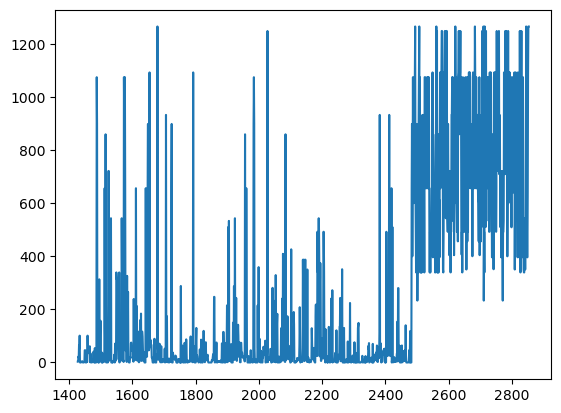

In [372]:
df7['intersectSize'].plot()

<AxesSubplot:>

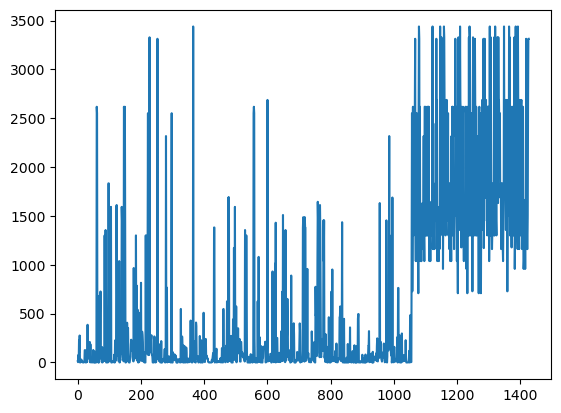

In [374]:
df30['intersectSize'].plot()

In [348]:
df['B']

0        53248
1        53248
2        53248
3        53248
4        53248
         ...  
2849    507904
2850    507904
2851    507904
2852    507904
2853    507904
Name: B, Length: 2854, dtype: int64

In [308]:
df_f = df1[df1['thrm33case2']]

In [281]:
df_bin2 = df_f[df_f['queryBin'] == 3]
len(df_bin2['queryText'].unique())

3

In [310]:
cnt = 0
cntf = 0
for i in df_f['queryText']:
    cnt+=1
    if 'ipSrcNet = 162196' in i:
        cntf +=1
    
print(cntf/cnt)

0.19047619047619047


In [309]:
getUsedAttrs(df)
getUsedAttrs(df_f)
getUsedAttrs(df_t)

['ipSrcNet', 'ipDst', 'ipDstHost', 'ipSrcHost', 'ipDstNet', 'ipSrc']
['ipSrcNet', 'ipDst', 'ipSrc', 'ipDstHost', 'ipSrcHost']
['ipSrcNet', 'ipDst', 'ipSrc', 'ipDstHost', 'ipSrcHost']


['ipSrcNet', 'ipDst', 'ipSrc', 'ipDstHost', 'ipSrcHost']

- make queries in different ways per f(q) size (5 or 10 bins)
    - for infrequent queries expect high error
    - infreq expect low error
- 

In [223]:
df_o = df[df['setting'] == "OmniSketch"]
df_w = df_o[~df_o['thrm33case2'] == True]

df_w['exactAnswer'].count()

900

In [386]:
df = read(dataset, True)
p = 3

df = preprocess(df, p, True)
dfo = df[df['setting'] == "OmniSketch"]

dfo = dfo[dfo['RAM'] == dfo['RAM'].iloc[-1]]
df_f = dfo[~dfo['thrm33case2']]
df_t = dfo[dfo['thrm33case2']]
df_t3 = df_t[df_t['queryBin'] == 2]
df_f3 = df_f[df_f['queryBin'] == 2]

In [387]:
df_f3['queryText'].unique()

array(['ipSrc = 1017997831 and ipSrcNet = 162196 and ipDstNet = 42251 and ipDstHost = 208160',
       'ipSrc = 1017997831 and ipSrcNet = 162196 and ipDst = 906596711 and ipDstNet = 42251 and ipDstHost = 208160',
       'ipSrc = 1017997831 and ipDst = 906596711 and ipDstNet = 42251 and ipDstHost = 208160',
       'ipSrc = 1017997831 and ipSrcNet = 162196 and ipSrcHost = 4976 and ipDstNet = 42251',
       'ipDst = 906596711 and ipDstNet = 42251 and ipDstHost = 208160',
       'ipSrc = 1017997831 and ipSrcHost = 4976 and ipDstNet = 42251',
       'ipSrc = 1017997831 and ipSrcNet = 162196 and ipDst = 906596711 and ipDstNet = 42251',
       'ipSrcNet = 162196 and ipSrcHost = 4976 and ipDst = 906596711 and ipDstNet = 42251',
       'ipSrcNet = 162196 and ipDstNet = 42251 and ipDstHost = 208160',
       'ipSrc = 1017997831 and ipSrcHost = 4976 and ipDstNet = 42251 and ipDstHost = 208160',
       'ipSrcNet = 42138 and ipDst = 1166948693 and ipDstNet = 54223 and ipDstHost = 235229',
       'ipS

In [388]:
df_t3['queryText'].unique()

array(['ipSrcHost = 4976 and ipDst = 906596711 and ipDstHost = 208160',
       'ipSrc = 1017997831 and ipSrcHost = 4976',
       'ipSrcNet = 162196 and ipDst = 906596711 and ipDstHost = 208160',
       'ipSrcNet = 162196 and ipSrcHost = 4976',
       'ipDst = 906596711 and ipDstNet = 42251',
       'ipSrcNet = 162196 and ipSrcHost = 4976 and ipDst = 906596711',
       'ipSrcNet = 42138 and ipDstHost = 235229',
       'ipSrcNet = 162196 and ipDst = 906596711',
       'ipSrc = 1017997831 and ipSrcNet = 162196',
       'ipSrc = 1017997831 and ipDst = 906596711 and ipDstHost = 208160',
       'ipSrc = 1017997831 and ipSrcNet = 162196 and ipDst = 906596711',
       'ipSrcNet = 162196 and ipSrcHost = 4976 and ipDst = 906596711 and ipDstHost = 208160',
       'ipSrc = 1017997831 and ipSrcNet = 162196 and ipSrcHost = 4976 and ipDstHost = 208160',
       'ipSrcNet = 162196 and ipDstNet = 42251',
       'ipSrc = 1017997831 and ipSrcNet = 162196 and ipSrcHost = 4976 and ipDst = 906596711 and ipDs

In [324]:
d = 4
eps = 0.1
epsCM = (eps**d/(1 + eps**d))**(1/d)

In [325]:
epsCM

0.09999750015623829

In [318]:
df_t3['queryText'].unique()

array(['ipSrcNet = 162196 and ipDst = 906596711',
       'ipSrc = 1017997831 and ipDstHost = 208160',
       'ipSrcHost = 4976 and ipDstHost = 208160',
       'ipSrcNet = 162196 and ipDstHost = 208160',
       'ipSrc = 1017997831 and ipDst = 906596711',
       'ipSrcHost = 4976 and ipDst = 906596711',
       'ipDst = 906596711 and ipDstHost = 208160'], dtype=object)

In [24]:
caida = pd.read_csv("C:/Users/s162378/OneDrive - TU Eindhoven/Documents/GitHub/DSCM/CAIDA/csv/equinix-chicago.dirA.20110217-125904.UTC.anon.pcap.csv")
dfc = caida
dfc.loc[:,'ip.src'] = dfc['ip.src'].apply(lambda x: str(x).replace('.',''))#.astype({'ip.src': float})



In [27]:
def find_subpops(c, d):
    dfc2 = dfc[[c, d]]
    dfc3 = dfc2.drop_duplicates()
    numsubpops = len(dfc2.drop_duplicates().index) + len(dfc2[c].unique()) + len(dfc2[d].unique())
    return numsubpops

In [28]:
for i in range(0, len(dfc.columns) - 1):
    c = dfc.columns[i]
    for j in range(i + 1, len(dfc.columns)):
        d = dfc.columns[j]
        print("Columns {} and {}".format(c, d))
        print("Have {} subpopulations.".format(find_subpops(c, d)))

Columns frame.number and frame.time
Have 14743648 subpopulations.
Columns frame.number and eth.src
Have 10154689 subpopulations.
Columns frame.number and eth.dst
Have 10154689 subpopulations.
Columns frame.number and ip.src
Have 10272608 subpopulations.
Columns frame.number and ip.dst
Have 10241523 subpopulations.
Columns frame.number and ip.proto
Have 10154695 subpopulations.
Columns frame.time and eth.src
Have 9177921 subpopulations.
Columns frame.time and eth.dst
Have 9177921 subpopulations.
Columns frame.time and ip.src
Have 9449151 subpopulations.
Columns frame.time and ip.dst
Have 9417562 subpopulations.
Columns frame.time and ip.proto
Have 9220767 subpopulations.
Columns eth.src and eth.dst
Have 3 subpopulations.
Columns eth.src and ip.src
Have 235841 subpopulations.
Columns eth.src and ip.dst
Have 173671 subpopulations.
Columns eth.src and ip.proto
Have 15 subpopulations.
Columns eth.dst and ip.src
Have 235841 subpopulations.
Columns eth.dst and ip.dst
Have 173671 subpopulation

In [15]:
dfc3 = dfc2.drop_duplicates()

In [16]:
len(dfc3.index)

245380

In [9]:
for c in dfc.columns:
    print("Card of column {} is {}".format(c,len(dfc[c].unique())))
    for d in dfc.columns:
        if c != d:
            print("#Subpopulations of {} and {} is {}".format(c, d, len(dfc[c].unique()) * len(dfc[d].unique())))

Card of column frame.number is 5077344
#Subpopulations of frame.number and frame.time is 23299728522240
#Subpopulations of frame.number and eth.src is 5077344
#Subpopulations of frame.number and eth.dst is 5077344
#Subpopulations of frame.number and ip.src is 598720404480
#Subpopulations of frame.number and ip.dst is 440891166240
#Subpopulations of frame.number and ip.proto is 35541408
Card of column frame.time is 4588960
#Subpopulations of frame.time and frame.number is 23299728522240
#Subpopulations of frame.time and eth.src is 4588960
#Subpopulations of frame.time and eth.dst is 4588960
#Subpopulations of frame.time and ip.src is 541130163200
#Subpopulations of frame.time and ip.dst is 398482341600
#Subpopulations of frame.time and ip.proto is 32122720
Card of column eth.src is 1
#Subpopulations of eth.src and frame.number is 5077344
#Subpopulations of eth.src and frame.time is 4588960
#Subpopulations of eth.src and eth.dst is 1
#Subpopulations of eth.src and ip.src is 117920
#Subpo

In [6]:
len(dfc['ip.src'].unique())*len(dfc['ip.dst'].unique())

10239583200

In [ ]:
df = pd.read_csv("C:/Users/s162378/OneDrive - TU Eindhoven/Documents/GitHub/DSCM/CAIDA/csv/equinix-chicago.dirA.20110217-125904.UTC.anon.pcap.csv")

In [284]:
cnt=0
for i in df_f3['queryText']:
    if "ipSrcNet = 162196" in i:
        cnt+=1
cnt/df_f3['queryText'].count()

0.12903225806451613

In [226]:
df_f3['B'].describe()

count      741.000000
mean     17459.951417
std      14864.339656
min       2720.000000
25%       5376.000000
50%      10624.000000
75%      26112.000000
max      51200.000000
Name: B, dtype: float64

In [233]:
(df_f3['intersectSize']/df_f3['B']).describe()

count    44.000000
mean      0.086244
std       0.007854
min       0.076152
25%       0.081582
50%       0.081582
75%       0.089434
max       0.102402
dtype: float64

In [235]:
(df_f3['intersectSize']/df_f3['B']).describe()

count    55.000000
mean      0.067010
std       0.006082
min       0.051250
25%       0.069355
50%       0.069355
75%       0.069355
max       0.069355
dtype: float64

deltaCM = 1/2, d = 4
eps 0.05: 2 / 10104
eps 0.1: 25 / 10104
eps 0.15: 73 / 10104

deltaCM 2/3, d = 4
eps 0.15: 73 / 10104

deltaCM 3/4, d = 4
eps 0.15: 73 / 10104

In [135]:
df1 = df[df['RAM'] == df['RAM'].iloc[-1]]
df1[df1['queryBin'] == 3].iloc[:,9:]

,numPredicates,exactAnswer,estimate,absError,relError,epsError,withinThreshold,estTime,queryText,exactTime,...,altNullAbsError,altNullEpsError,d,w,B,b,dCS,wCS,levels,k
5171,2,123439.0,119933.0,3506.0,0.0284,0.0007,True,19,ipDst = -1838419300 and ipDstNet = 195200,0,...,3506.0,0.000691,4,6,51200,32,0,0,0,0
5196,2,123439.0,119933.0,3506.0,0.0284,0.0007,True,26,ipDstNet = 195200 and ipDstHost = 93245,0,...,3506.0,0.000691,4,6,51200,32,0,0,0,0
5234,2,123439.0,120952.0,2487.0,0.0201,0.0005,True,19,ipDst = -1838419300 and ipDstHost = 93245,0,...,2487.0,0.000490,4,6,51200,32,0,0,0,0
5235,2,123439.0,119933.0,3506.0,0.0284,0.0007,True,19,ipDstNet = 195200 and ipDstHost = 93245,0,...,3506.0,0.000691,4,6,51200,32,0,0,0,0
5256,2,123439.0,119933.0,3506.0,0.0284,0.0007,True,19,ipDst = -1838419300 and ipDstNet = 195200,0,...,3506.0,0.000691,4,6,51200,32,0,0,0,0
5263,2,140059.0,133395.0,6664.0,0.0476,0.0013,True,30,ipSrcNet = 1987 and ipDstNet = 1986,0,...,6664.0,0.001312,4,6,51200,32,0,0,0,0
5268,2,123439.0,119933.0,3506.0,0.0284,0.0007,True,18,ipDst = -1838419300 and ipDstNet = 195200,0,...,3506.0,0.000691,4,6,51200,32,0,0,0,0
5269,2,123439.0,119933.0,3506.0,0.0284,0.0007,True,19,ipDstNet = 195200 and ipDstHost = 93245,0,...,3506.0,0.000691,4,6,51200,32,0,0,0,0
5337,2,123439.0,119933.0,3506.0,0.0284,0.0007,True,21,ipDstNet = 195200 and ipDstHost = 93245,0,...,3506.0,0.000691,4,6,51200,32,0,0,0,0
5338,2,123439.0,120952.0,2487.0,0.0201,0.0005,True,19,ipDst = -1838419300 and ipDstHost = 93245,0,...,2487.0,0.000490,4,6,51200,32,0,0,0,0


In [136]:
df_t3 = df_t[df_t['queryBin'] == 2]

dfr = df[~df.index.isin(df_t3.index)]

In [131]:
df = read(dataset, True)
p = 3

df = preprocess(df, p)

df_t = df[~df['thrm33case2']]

Distinct queries: 372
DF com unique: ['Sketch0Min' 'Sketch0Cap' 'OmniSketch']
[77.42710472  0.          0.          0.        ]
[35.42505133  0.          0.          0.        ]
[0.         0.63039014 2.22997947 3.86652977]


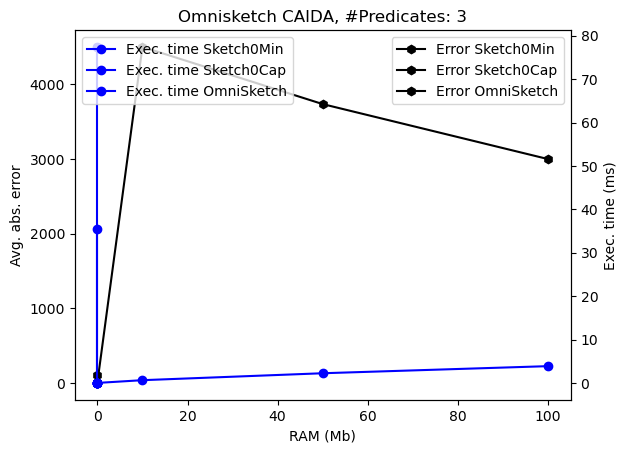

Distinct queries: 372
DF com unique: ['Sketch0Min' 'Sketch0Cap' 'OmniSketch']
[0.01068531 0.         0.         0.        ]
[0.0105829 0.        0.        0.       ]
[0.         0.00116183 0.00207825 0.00328636]


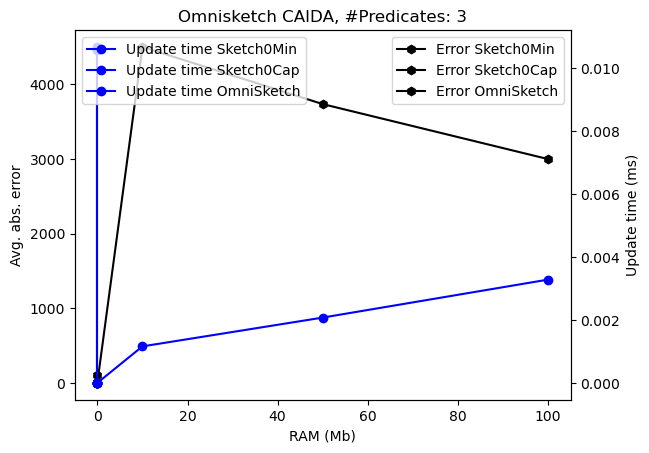

Null estimate


In [132]:
aggr = 'altAbsError'
compareBaselinePlot(df, dataset, aggr)
print("Null estimate")

Distinct queries: 67
DF com unique: ['OmniSketch']
[ 0.87769784  1.8705036   2.77697842  2.76978417  3.47482014  8.07194245
 13.3381295  20.64748201]


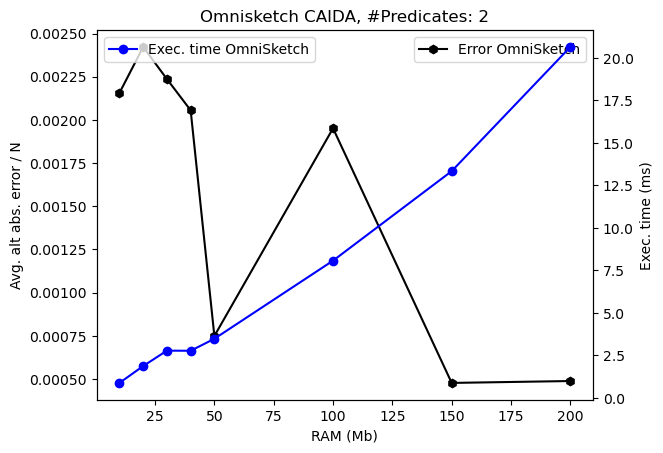

Distinct queries: 67
DF com unique: ['OmniSketch']
[0.01027368 0.01323389 0.0146362  0.01473389 0.01258197 0.0140286
 0.01556976 0.01570073]


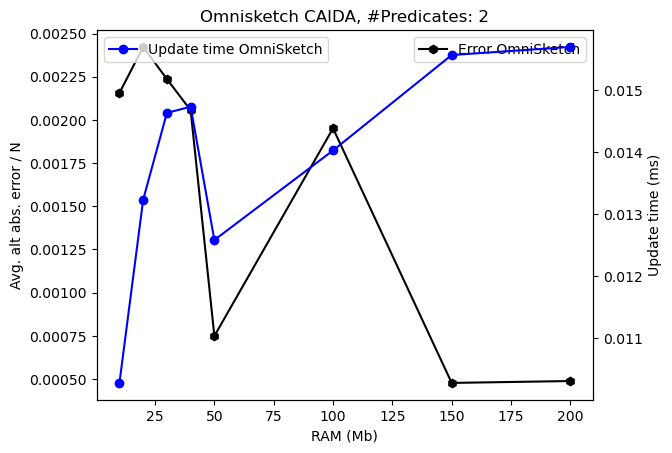

2 preds


In [685]:
aggr = 'altEpsError'
compareBaselinePlot(df, dataset, aggr)
print("2 preds")

In [303]:
df = read(dataset, True)
p = 3
df = preprocess(df, p)

Distinct queries: 295
DF com unique: ['OmniSketch']
[0.35135135 1.         0.73310811 1.47635135 1.37837838 2.66891892
 4.12837838 8.7972973 ]


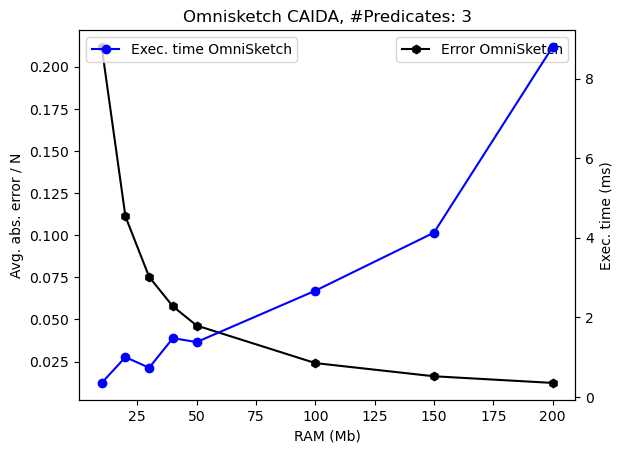

Distinct queries: 295
DF com unique: ['OmniSketch']
[0.00271441 0.00305908 0.00337598 0.00367417 0.00388944 0.00488878
 0.00615893 0.00830749]


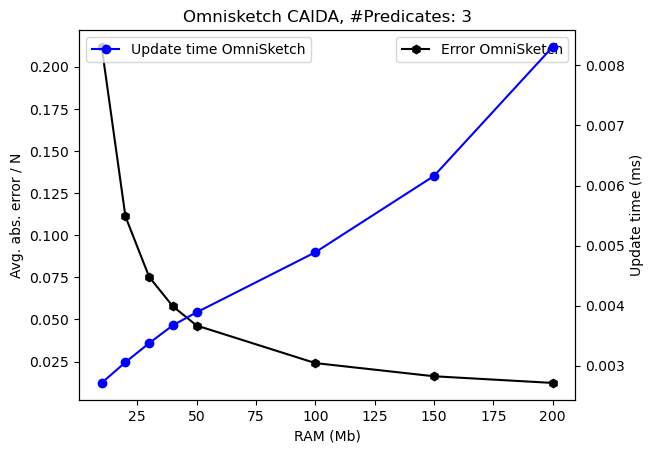

3 preds


In [519]:
compareBaselinePlot(df, dataset)
print("3 preds")

In [520]:
df = read(dataset, True)
p = 4
df = preprocess(df, p)

Distinct queries: 346
DF com unique: ['OmniSketch']
[0.3699422  0.96531792 0.72254335 1.43641618 1.2716763  2.47976879
 3.85260116 8.05491329]


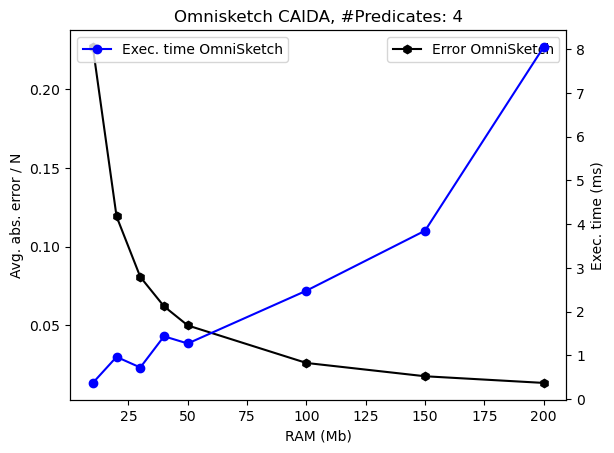

Distinct queries: 346
DF com unique: ['OmniSketch']
[0.00271441 0.00305908 0.00337598 0.00367417 0.00388944 0.00488878
 0.00615893 0.00830749]


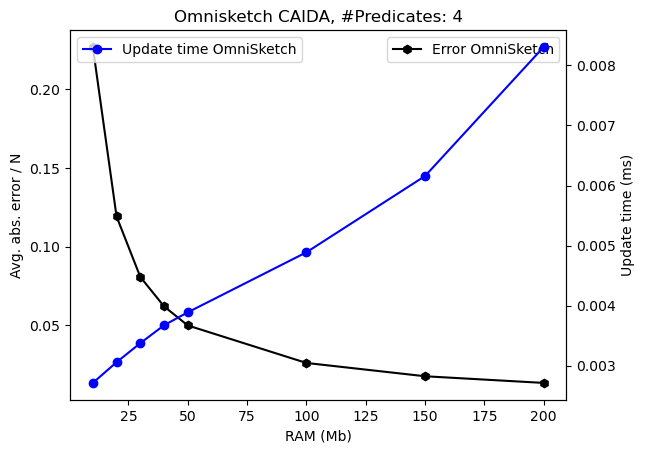

4 preds


In [521]:
compareBaselinePlot(df, dataset)
print("4 preds")

In [501]:
df['streamSize'].unique()

array([5077343], dtype=int64)

In [502]:
d = 4
p = 2
delta = 0.025
np.log(2*d*p/delta)/(0.01**2) * (1/0.1) * 2

1292293.6352707434

In [92]:
B = 24840
4 * B * B * np.sqrt(B)

388990477658.56976

In [93]:
3905440 / 4 * (24/32 * 4)

2929080.0

In [94]:
d: 4.0 w: 5.0 b: 6974.0

SyntaxError: invalid syntax (3075938132.py, line 1)

In [ ]:
B = 241733
b = np.log(4*B*B*np.sqrt(B)/0.025)
4 * 7 * (B * b/32 * 4 + 4)  * 10

In [ ]:
dfs = df[df['setting'] == 'Sketch']
dfh = df[df['setting'] == 'Hydra']

In [ ]:
dfs.plot.scatter('RAM', 'absError')
dfh.plot.scatter('RAM', 'absError')

In [ ]:
dfh['absError'].describe()

In [ ]:
dfh.columns

In [ ]:
dfh['Sketch Memory (Mb)']/dfh['RAM']

In [ ]:
dfs['Sketch Memory (Mb)']/dfs['RAM']

In [ ]:
4*4*4103*7*4/1e6

In [ ]:
d: 4.0 w: 5.0 b: 8626.0

In [ ]:
B = 8626
d = 4
w = 5
A = 7
byteInt = 4

mem = B*d*w*A*byteInt/1e6

In [ ]:
mem

In [ ]:
d = 4
w = 11
dCM =4
wCM = 6212
byteInt = 4

memH = d*w*dCM*wCM*byteInt/1e6

In [ ]:
memH

In [ ]:
eps = 0.1
d = 4
epsCM = (eps**d/(1 + eps**d))**(1/d)
epsCM

In [ ]:
Math.pow((Math.pow(eps, depth)/(1 + Math.pow(eps, depth))), (1/depth));

In [ ]:
np.log(2/0.025)
eps = 1*10**(-7)
d = 4

In [ ]:
B = 12 * np.log(2/0.025)/(0.01*eps**d)

In [ ]:
B